# Car price — Decision Tree
Data, model-name cleanup and train/val/test split come from the Setup cell = identical to `linear_regression.ipynb` sections 1–2.

- Features (chosen in `variable_selection.ipynb`): engine_capacity, mileage, car_age + brand, model, car_type, fuel_type, gear_type (integer codes)
- Target = `log(price)`; metrics on the price scale. No assumption tests (trees do not assume linearity / normal / constant-variance residuals).

## Setup
Settings and shared data prep, inlined so this notebook runs on its own (only `data/car_dataset_v5.1.csv` is needed).

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

class C:  # settings (was config.py)
    DATA_PATH = "data/car_dataset_v5.1.csv"   # relative to this notebook; sha256 d2c6f2c9... (LF line endings)
    SEED = 99
    TARGET = "price"
    NUM_COLS = ["engine_capacity", "mileage", "car_age"]
    DROP_COLS = ["year"]              # year == 2026 - car_age exactly (variable_selection.ipynb layer 1)
    MAX_CAR_AGE = 25                 # rows with car_age > MAX_CAR_AGE are removed (classic / collector cars)
    MODEL_ALIASES = {"ALTIS": "COROLLAALTIS", "NP300NAVARA": "NAVARA"}
    TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 0.70, 0.15, 0.15


# variables chosen in variable_selection.ipynb (layer 1: year = exact duplicate; layer 2: permutation importance)
CATS = ["brand", "model", "car_type", "fuel_type", "gear_type"]
FEATS = C.NUM_COLS + CATS
# final MLR test result, from linear_regression.ipynb section 10 (update by hand if the MLR changes)
LR_TEST = dict(model="MLR final (from LR notebook)", RMSE=192_232, MAE=85_432, MAPE=0.1380, R2=0.9050)


def load():
    df = pd.read_csv(C.DATA_PATH)
    assert (df["year"] + df["car_age"]).nunique() == 1, "year/car_age no longer redundant"
    n0 = len(df); df = df[df["car_age"] <= C.MAX_CAR_AGE]
    print(f"removed {n0 - len(df)} rows with car_age > {C.MAX_CAR_AGE}")
    df = df.drop(columns=C.DROP_COLS)
    # model-name cleanup (no target used): compare names without spaces/hyphens, merge aliases, show most common spelling
    df["model_raw"] = df["model"]
    key = df["model"].str.upper().str.replace(r"[^A-Z0-9]", "", regex=True).replace(C.MODEL_ALIASES)
    df["model"] = key.map(df.groupby(key)["model_raw"].agg(lambda s: s.value_counts().index[0]))
    return df


def split(df):
    """One random car of every (brand, model) goes to train first, so no model is train-unseen."""
    forced = df.groupby(["brand", "model"]).sample(n=1, random_state=C.SEED)
    rest = df.drop(forced.index)
    train_rest, temp = train_test_split(rest, train_size=round(C.TRAIN_SIZE * len(df)) - len(forced), random_state=C.SEED)
    val, test = train_test_split(temp, test_size=C.TEST_SIZE / (C.VAL_SIZE + C.TEST_SIZE), random_state=C.SEED)
    return pd.concat([forced, train_rest]), val, test


def features(d, train, codes):
    """codes=True -> integer codes (DT/RF, unseen -> -1); False -> pandas categorical (XGBoost native)."""
    X = d[FEATS].copy()
    for c in CATS:
        levels = sorted(train[c].unique())
        X[c] = pd.Categorical(d[c].where(d[c].isin(levels)), categories=levels)
        if codes:
            X[c] = X[c].cat.codes
    return X


def get_data(codes):
    train, val, test = split(load())
    X = {k: features(d, train, codes) for k, d in dict(train=train, val=val, test=test).items()}
    return train, val, test, X


def pick(tune, tol=0.02):
    """Least-overfit config among those within tol of the best val MAE (a 1-SE-style rule: near-best accuracy, smallest train/val gap)."""
    ok = tune[tune["MAE"] <= tune["MAE"].min() * (1 + tol)]
    return ok["gap"].idxmin()


def score(name, y, pred, **extra):
    return dict(model=name, RMSE=mean_squared_error(y, pred) ** 0.5, MAE=mean_absolute_error(y, pred),
                MAPE=np.mean(np.abs(pred / y - 1)), R2=r2_score(y, pred), **extra)


def tune_row(m, X, train, val, **extra):
    r = score("val", val[C.TARGET], np.exp(m.predict(X["val"])), **extra)
    r["train_MAE"] = mean_absolute_error(train[C.TARGET], np.exp(m.predict(X["train"]))); r["gap"] = r["MAE"] / r["train_MAE"]
    return r


def test_table(name, best, X, test, tune, i):
    pred = np.exp(best.predict(X["test"]))
    r = score(name, test[C.TARGET], pred, params=tune.loc[i, "params"], train_MAE=tune.loc[i, "train_MAE"], val_MAE=tune.loc[i, "MAE"], val_R2=tune.loc[i, "R2"])
    return pred, pd.DataFrame([r, LR_TEST]).set_index("model").round(4)


def plot_test(name, test, pred):
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(test[C.TARGET], pred, s=4, alpha=.3)
    lim = [test[C.TARGET].min(), test[C.TARGET].max()]; ax.plot(lim, lim, "r--", lw=1)
    ax.set(xscale="log", yscale="log", title=f"{name}  test R2={r2_score(test[C.TARGET], pred):.3f}", xlabel="actual", ylabel="predicted")


def importance(best, X, val, n_jobs=-1):
    pi = permutation_importance(best, X["val"], np.log(val[C.TARGET]), n_repeats=5, random_state=C.SEED, n_jobs=n_jobs)
    imp = pd.DataFrame({"built-in": best.feature_importances_, "permutation (val)": pi.importances_mean}, index=FEATS)
    return imp.div(imp.sum()).sort_values("permutation (val)", ascending=False).round(3)


def error_tables(best, X, val):
    v = val.assign(pred=np.exp(best.predict(X["val"])))
    v["abs_err"] = (v["pred"] - v[C.TARGET]).abs(); v["ape"] = v["abs_err"] / v[C.TARGET]
    v["age_bin"] = pd.cut(v["car_age"], [-1, 2, 5, 8, 12, 16, 20, 25])
    by_age = v.groupby("age_bin", observed=True).agg(n=("ape", "size"), MAE=("abs_err", "mean"), MAPE=("ape", "mean")).round(3)
    by_model = (v.groupby(["brand", "model"]).agg(n=("ape", "size"), MAE=("abs_err", "mean"), MAPE=("ape", "mean"), med_price=(C.TARGET, "median"))
                .query("n >= 10").sort_values("MAE", ascending=False).head(15).round(3))
    return by_age, by_model

In [2]:
import time, numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

pd.set_option("display.width", 200, "display.max_columns", 50)
train, val, test, X = get_data(codes=True)
y_log = np.log(train[C.TARGET])
print({k: len(v) for k, v in X.items()}, X['train'].shape)

removed 287 rows with car_age > 25


{'train': 20872, 'val': 4472, 'test': 4473} (20872, 8)


## 1. Tune on validation
Small grid; the test set is not touched here. `gap` = val MAE / train MAE (1 = no overfit).

Selection (`pick`): among configs within 2% of the best val MAE, take the one with the smallest gap — near-best accuracy, least overfit.

In [3]:
rows, models = [], []
for p in [dict(max_depth=d, min_samples_leaf=l, ccp_alpha=a) for d in [20, None] for l in [1, 5, 10] for a in [0, 1e-5, 3e-5, 1e-4]]:
    m = DecisionTreeRegressor(**p, random_state=C.SEED)
    t = time.time(); m.fit(X['train'], y_log)
    r = tune_row(m, X, train, val, params=str(p), sec=round(time.time() - t, 1))
    rows.append(r); models.append(m)
tune = pd.DataFrame(rows).drop(columns='model')
tune.sort_values('MAE').round(4)

,RMSE,MAE,MAPE,R2,params,sec,train_MAE,gap
13,279356.5204,89513.6047,0.1366,0.8322,"{'max_depth': None, 'min_samples_leaf': 1, 'cc...",2.9,64853.5141,1.3802
1,280088.5561,89610.2414,0.1360,0.8314,"{'max_depth': 20, 'min_samples_leaf': 1, 'ccp_...",2.1,64880.8051,1.3812
0,267858.1277,90947.4644,0.1453,0.8458,"{'max_depth': 20, 'min_samples_leaf': 1, 'ccp_...",0.2,11782.3950,7.7189
12,269100.1894,91462.0230,0.1474,0.8443,"{'max_depth': None, 'min_samples_leaf': 1, 'cc...",0.1,6670.2441,13.7119
8,272620.7066,97068.1869,0.1435,0.8402,"{'max_depth': 20, 'min_samples_leaf': 10, 'ccp...",0.1,91377.8583,1.0623
20,272621.5364,97068.9627,0.1435,0.8402,"{'max_depth': None, 'min_samples_leaf': 10, 'c...",0.1,91376.5378,1.0623
4,303978.6644,97872.8553,0.1412,0.8014,"{'max_depth': 20, 'min_samples_leaf': 5, 'ccp_...",0.1,74458.2277,1.3145
17,303118.5053,97874.2054,0.1405,0.8025,"{'max_depth': None, 'min_samples_leaf': 5, 'cc...",0.1,83615.1747,1.1705
5,303121.2901,97886.8810,0.1405,0.8025,"{'max_depth': 20, 'min_samples_leaf': 5, 'ccp_...",0.1,83615.1747,1.1707
21,274159.0720,97888.7017,0.1448,0.8384,"{'max_depth': None, 'min_samples_leaf': 10, 'c...",0.1,95522.0449,1.0248


## 2. Best params → evaluate test once

In [4]:
i = pick(tune); best = models[i]
pred_te, res = test_table('Decision Tree', best, X, test, tune, i)
res

,RMSE,MAE,MAPE,R2,params,train_MAE,val_MAE,val_R2
model,,,,,,,,
Decision Tree,228734.315,89432.0785,0.1439,0.8655,"{'max_depth': None, 'min_samples_leaf': 1, 'cc...",64853.5141,89513.6047,0.8322
MLR final (from LR notebook),192232.000,85432.0000,0.1380,0.9050,NaN,NaN,NaN,NaN


## 3. Actual vs predicted (test, price scale)

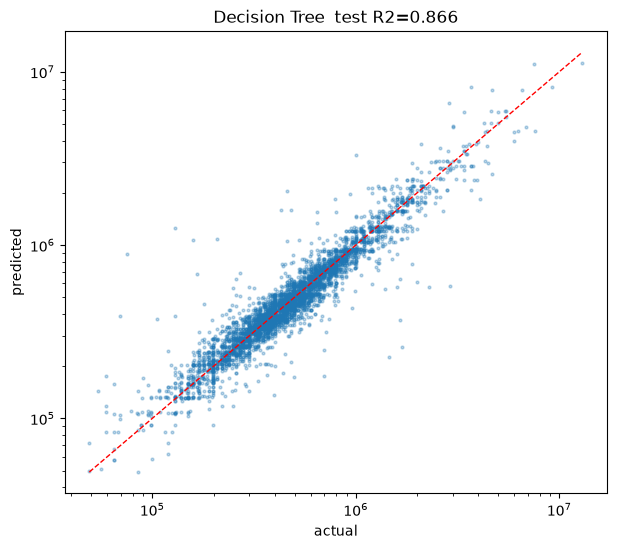

In [5]:
plot_test('Decision Tree', test, pred_te)

## 4. Feature importance
Built-in (impurity/gain) importance is biased toward high-cardinality features (`model` ~490 levels), so permutation importance on validation is shown next to it.

In [6]:
importance(best, X, val)

,built-in,permutation (val)
engine_capacity,0.298,0.342
car_age,0.352,0.273
model,0.085,0.118
car_type,0.104,0.112
brand,0.072,0.097
fuel_type,0.023,0.028
mileage,0.057,0.019
gear_type,0.009,0.012


## 5. Where is the error? (validation, price scale)

In [7]:
by_age, by_model = error_tables(best, X, val)
display(by_age)
by_model

,n,MAE,MAPE
age_bin,,,
"(-1, 2]",245,260740.603,0.145
"(2, 5]",1264,104364.029,0.112
"(5, 8]",1352,72926.346,0.114
"(8, 12]",964,72163.146,0.141
"(12, 16]",461,48652.275,0.171
"(16, 20]",126,77218.514,0.376
"(20, 25]",60,69788.913,0.293


n         MAE   MAPE  med_price
brand         model                                     
PORSCHE       CAYENNE   27  540995.546  0.176  2990000.0
MERCEDES-BENZ E220      10  289335.271  0.326  1009500.0
              E300      19  257227.306  0.192  1259000.0
              C220      15  227929.651  0.199  1150000.0
TOYOTA        ALPHARD   57  207562.584  0.133  1780000.0
HYUNDAI       STARIA    12  191783.390  0.145  1024500.0
BMW           X5        13  170450.811  0.138  1860000.0
              X3        12  168091.348  0.198   604000.0
TOYOTA        VELLFIRE  50  160549.688  0.124  1344000.0
BMW           330E      23  150776.000  0.151   998000.0
              530E      35  143735.815  0.140   950000.0
MINI          COOPER    16  130201.497  0.166   496500.0
FORD          EVEREST   71  128959.180  0.155   743000.0
MERCEDES-BENZ C300      14  127085.332  0.133   879000.0
              GLA200    28  124791.319  0.134   989000.0